In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from load_meop import MEOP
from region import Region
pfns = PlottingFns()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import xesmf as xe
import matplotlib.patches as mpatches
from tqdm import tqdm


ARGO = '/nfs/b0133/eejco/data/ARGO/DataSelection_a0ad0869-68c3-4b7d-af4c-9c010ab6e378/'




In [4]:
#define helper functions
def get_trend(da: xr.DataArray,ns=True):
    ns_2_yr = lambda x: x * 1e9 * 60 * 60 * 24 * 365.25
    p = da.polyfit(dim='time',deg=1)
    m = p.polyfit_coefficients.sel(degree=1)
    m = m.assign_coords(longitude=da.longitude)
    return ns_2_yr(m) if ns else m

def crop_to_extent(ds, extent):
    return ds.where((ds.latitude >= extent[2]) & 
                    (ds.latitude <= extent[3]) &
                    (ds.longitude >= extent[0]) &
                    (ds.longitude <= extent[1]), drop=True)

def season_split(da):
    # divide by season
    months = da.time.dt.month
    seasons = dict()
    seasons['winter'] = da.where((months >=7) & (months <=9))
    seasons['spring'] = da.where((months >=10) & (months <=12))
    seasons['summer'] = da.where((months >=1) & (months <=3))
    seasons['autumn'] = da.where((months >=4) & (months <=6))
    return seasons

def seasonal_anomaly(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()


In [5]:
mertz = [144.25,-67.5]

In [6]:
lwe_ds = GRACE().ds
sla = SLA(deg=0.25).da
dot_ds = DOT().ds

In [7]:
elevation_ = GEBCO(coarsen_factor=10).ds.elevation
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')
sice = sice.__xarray_dataarray_variable__

In [137]:
extent =[138,143.5,-67.05,-65]

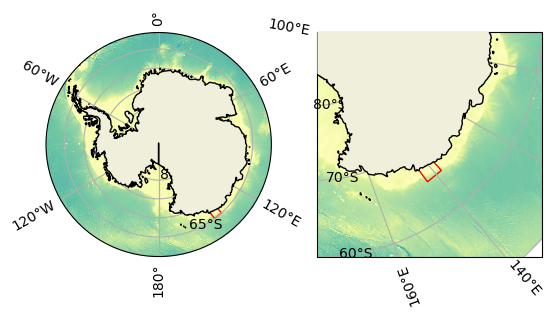

In [138]:
fig, ax = plt.subplots(1,2,subplot_kw={"projection":ccrs.SouthPolarStereo()})
pfns.sp(ax[0],elevation_,sea='Small Southern Ocean')
extent = extent
ax[0].add_patch(mpatches.Rectangle(xy=[extent[0], extent[2]],
                                width=extent[1]-extent[0],
                                height=extent[3]-extent[2],
                                facecolor='none', edgecolor='r',
                                transform=ccrs.PlateCarree()))
pfns.sp(ax[1],elevation_,extent=[90,180,-80,-60])
ax[1].add_patch(mpatches.Rectangle(xy=[extent[0], extent[2]],
                                width=extent[1]-extent[0],
                                height=extent[3]-extent[2],
                                facecolor='none', edgecolor='r',
                                transform=ccrs.PlateCarree()))

In [140]:
# crop elevation
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))

In [11]:
sha_ds_sla = StericHeight(ssh_ref='DOT',
                      ssh=sla,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()

In [142]:
meop=MEOP(extent=extent)

In [ ]:
meop.load_profiles(full=True)

 44%|████▍     | 36/82 [01:15<01:34,  2.06s/it]

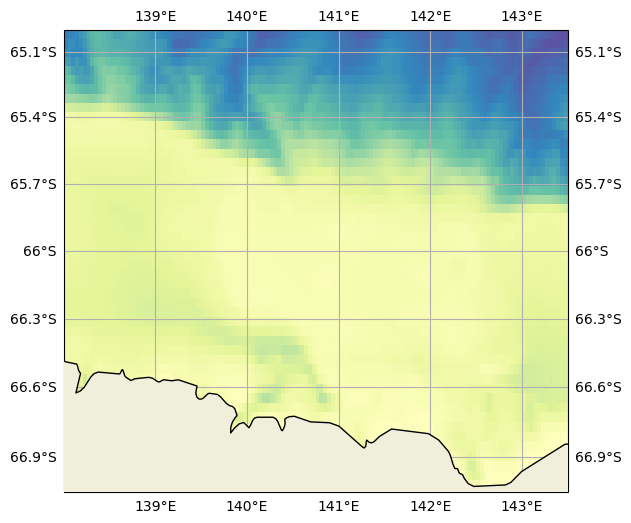

In [141]:
fig, ax = plt.subplots(figsize=(10,6), subplot_kw={'projection':ccrs.Mercator()})
pfns.sp(ax=ax,da=elevation,extent=extent)

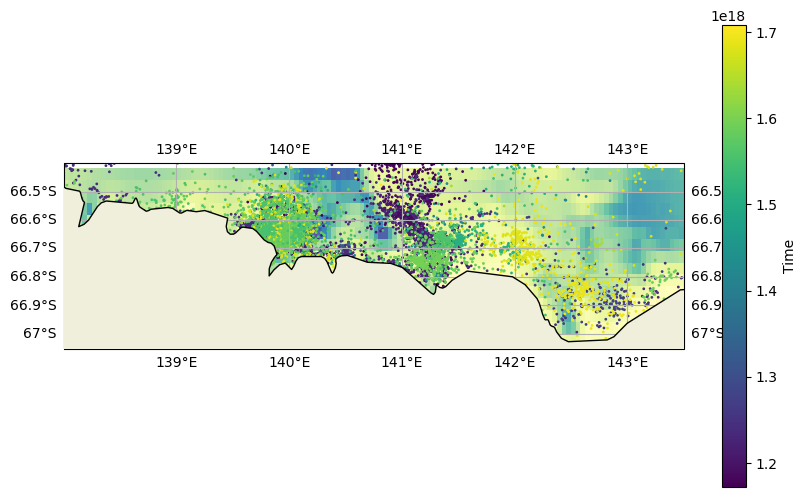

In [ ]:
fig, ax = plt.subplots(figsize=(10,6), subplot_kw={'projection':ccrs.Mercator()})
pfns.sp(ax=ax,da=elevation,extent=extent)
im=ax.scatter(meop.df.longitude, meop.df.latitude, [1 for t in meop.df.index], meop.df.index, transform=ccrs.PlateCarree())
cbar = plt.colorbar(im, label='Time')


In [ ]:
sha_cropped = crop_to_extent(sha_ds_sla,extent)
meop.grid_profiles(sha_cropped.longitude.to_numpy(),sha_cropped.latitude.to_numpy())

100%|██████████| 23/23 [00:00<00:00, 35.37it/s]


merging...


In [ ]:
# SINGLE DS WITH GRIDDED SHA and GPH FOR MRTZ
sha_gph_ = xr.merge([sha_cropped.where(sha_cropped.time > meop.gridded_profiles.time[0],drop=True),
                     meop.gridded_profiles.where(meop.gridded_profiles.time < sha_cropped.time[-1],drop=True)])


In [ ]:
sha_gph_

<xarray.Dataset> Size: 1MB
Dimensions:            (longitude: 23, latitude: 3, time: 179)
Coordinates:
  * longitude          (longitude) float64 184B 138.0 138.2 ... 143.2 143.5
  * latitude           (latitude) float64 24B -67.0 -66.75 -66.5
  * time               (time) datetime64[ns] 1kB 2007-02-01 ... 2021-12-01
Data variables:
    ssh                (time, latitude, longitude) float64 99kB nan ... -12.81
    lwe                (time, latitude, longitude) float64 99kB nan ... 5.247
    msl                (time, latitude, longitude) float64 99kB nan nan ... nan
    msla               (time, latitude, longitude) float64 99kB nan nan ... nan
    ssha               (time, latitude, longitude) float64 99kB nan ... -14.75
    eha                (time, latitude, longitude) float64 99kB nan ... 2.868
    sha                (time, latitude, longitude) float64 99kB nan ... -17.75
    profile_gph        (longitude, latitude, time) float64 99kB nan nan ... nan
    profile_latitude   (longitude, latitude, time) float64 99kB nan nan ... nan
    profile_longitude  (longitude, latitude, time) float64 99kB nan nan ... nan
    profile_cnt        (longitude, latitude, time) float64 99kB nan nan ... nan

In [ ]:
profile_gph_ungridded = meop.df.dropna().gph.groupby(pd.Grouper(freq='MS')).mean().to_xarray().rename({'index':'time'})

In [ ]:
sha_gph_['profile_gpha'] = 100*(sha_gph_.profile_gph - sha_gph_.profile_gph.mean('time'))

Adding row: Mertz
Adding row: Mertz
Adding row: Mertz
Adding row: Mertz
Adding row: Mertz
Rendering..


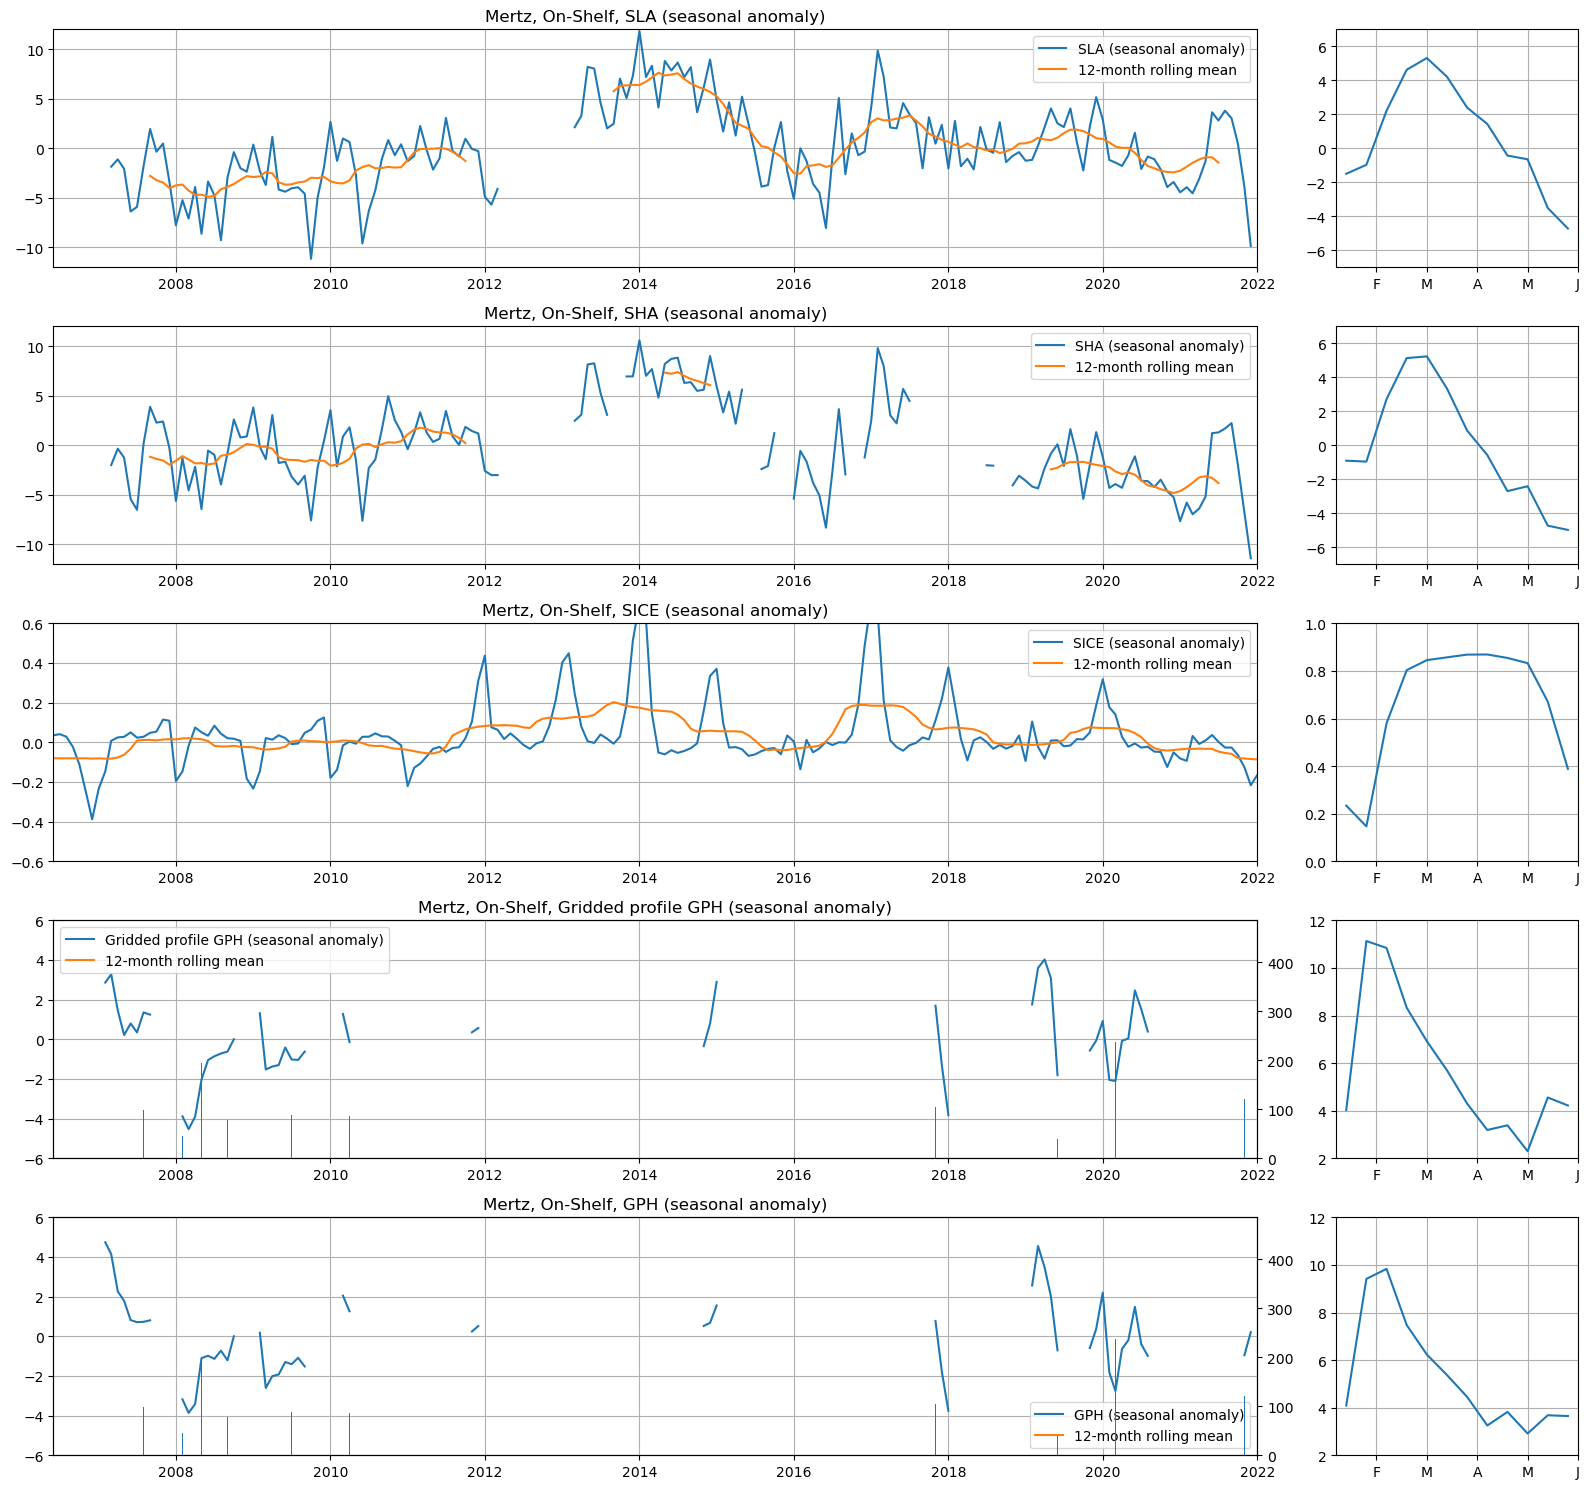

In [ ]:
# compare small mertz area to:
# - extended shelf region (135-145)
# - EA south of Amery
# - whole SO (shelf)
fig = plt.figure(figsize=(16,15))
axs=[]

gs = fig.add_gridspec(5,5)

def add_row_anom(n,var,varname,title,extent,shelf=False,ylim=[-12,12],ylim_cmt=[-7,7]):

    print('Adding row: ' + title)

    axs.append(fig.add_subplot(gs[n,0:4]))
    axs.append(fig.add_subplot(gs[n,4:6]))

    if shelf == True:
        region = Region(title, extent, elevation, min_elevation = -1000)
    else:
        region = Region(title, extent, elevation)


    if varname == 'GPH':
        da = var
    else:
        da = region.crop_da(var).mean(['latitude','longitude'])

    ax = axs[(n*2)]

    cmt = da.groupby('time.month').mean()
    anm = da.groupby('time.month') - cmt
    varname = varname + ' (seasonal anomaly)'

    ax.plot(anm.time,anm,label=varname)
    ax.plot(anm.time,anm.rolling(time=12,center=True).mean(),label='12-month rolling mean')

    shelf_str = 'On' if shelf else 'On and Off'
    ax.set_title(title +', '+shelf_str+'-Shelf, ' + varname)
    ax.legend(loc='best')
    ax.set_ylim(ylim)
    ax.set_xlim([pd.Timestamp(2006,6,1),pd.Timestamp(2022,1,1)])
    ax.grid()

    ax = axs[(n*2)+1]

    ax.plot(cmt.month,cmt)
    ax.set_ylim(ylim_cmt)
    ax.grid()
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlim([0.5,12.5])


add_row_anom(0,sha_gph_.ssha,'SLA','Mertz',extent,shelf=True)
add_row_anom(1,sha_gph_.sha,'SHA','Mertz',extent,shelf=True)
add_row_anom(2,sice,'SICE','Mertz',extent,shelf=True,ylim=[-0.6,0.6],ylim_cmt=[0,1])
add_row_anom(3,sha_gph_.profile_gph*100,'Gridded profile GPH','Mertz',extent,shelf=True,ylim_cmt=[2,12],ylim=[-6,6])
add_row_anom(4,profile_gph_ungridded*100,'GPH','Mertz',extent,shelf=True,ylim_cmt=[2,12],ylim=[-6,6])

axs[6].twinx().bar(sha_gph_.time,sha_gph_.profile_cnt.sum(['latitude','longitude']))
axs[8].twinx().bar(profile_gph_ungridded.time,meop.df.dropna().gph.groupby(pd.Grouper(freq='MS')).count())


plt.tight_layout()
print('Rendering..')


Adding row: Mertz
Adding row: Mertz
Adding row: Mertz
Adding row: Mertz
Rendering..


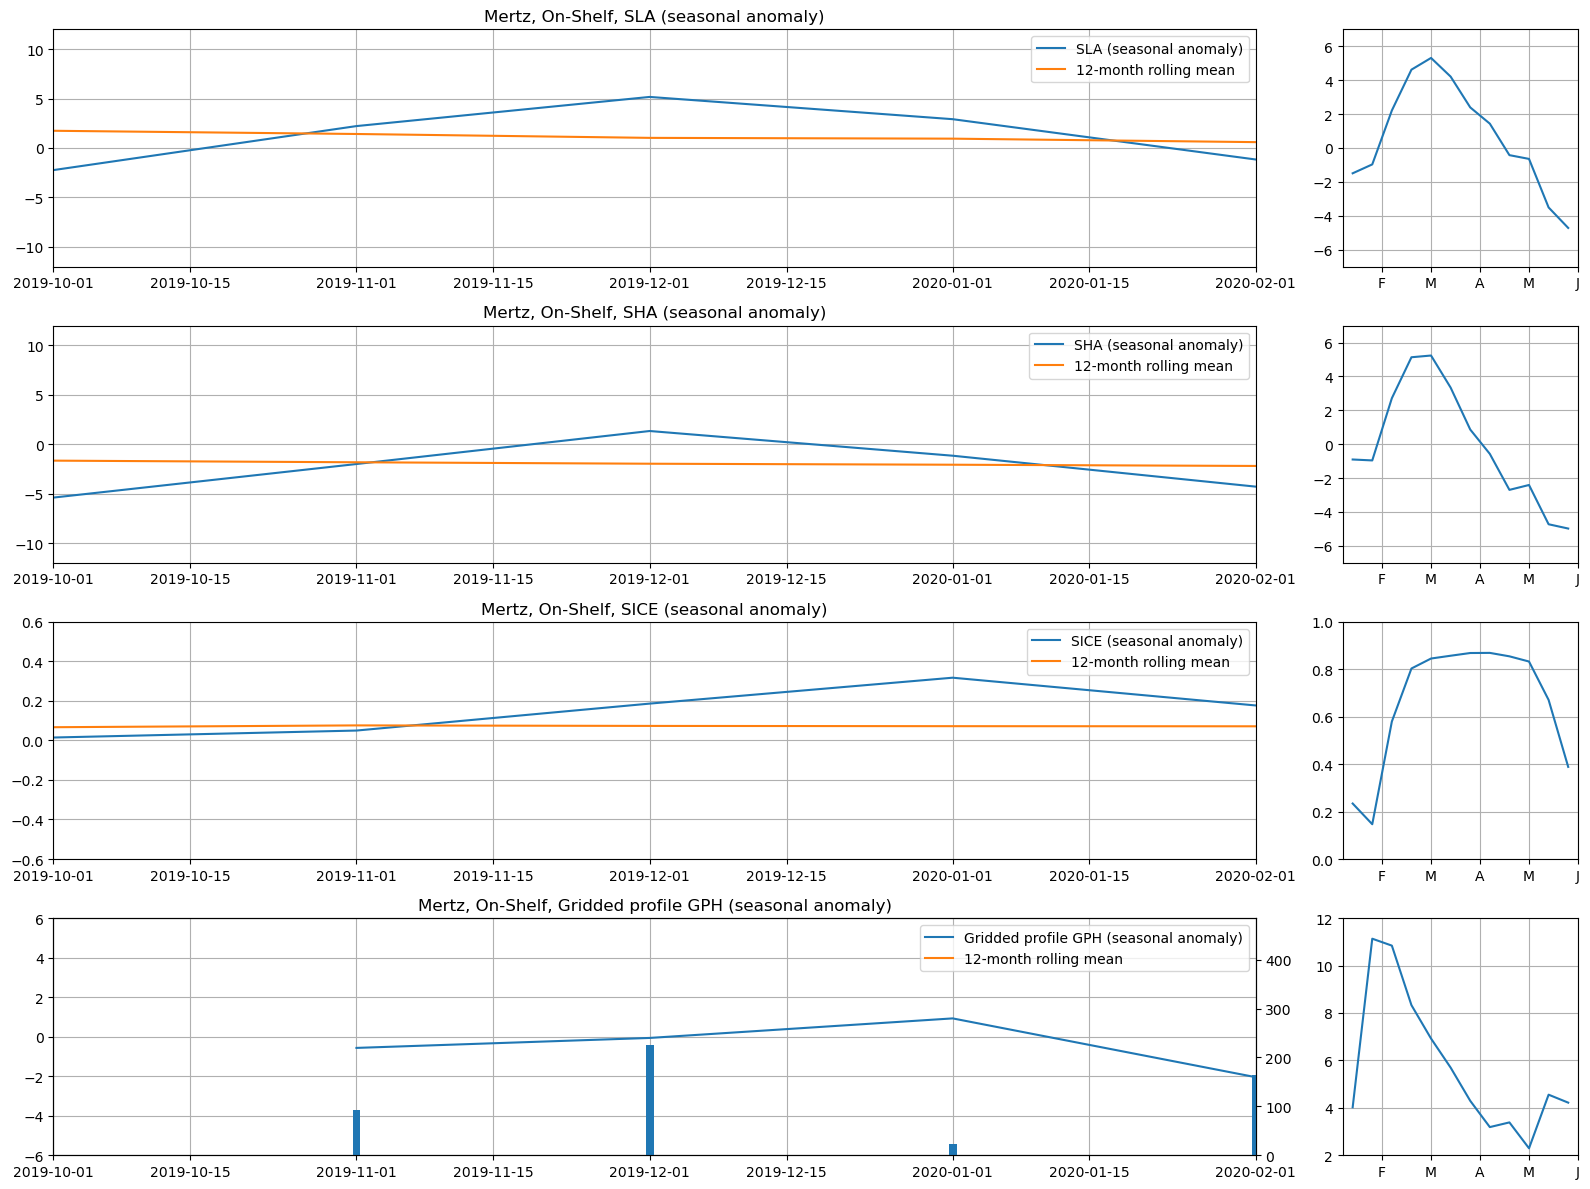

In [60]:
# compare small mertz area to:
# - extended shelf region (135-145)
# - EA south of Amery
# - whole SO (shelf)
fig = plt.figure(figsize=(16,12))
axs=[]

gs = fig.add_gridspec(4,5)

def add_row_anom(n,var,varname,title,extent,shelf=False,ylim=[-12,12],ylim_cmt=[-7,7]):

    print('Adding row: ' + title)

    axs.append(fig.add_subplot(gs[n,0:4]))
    axs.append(fig.add_subplot(gs[n,4:6]))

    if shelf == True:
        region = Region(title, extent, elevation, min_elevation = -1000)
    else:
        region = Region(title, extent, elevation)


    if varname == 'GPH':
        da = var
    else:
        da = region.crop_da(var).mean(['latitude','longitude'])

    ax = axs[(n*2)]

    cmt = da.groupby('time.month').mean()
    anm = da.groupby('time.month') - cmt
    varname = varname + ' (seasonal anomaly)'

    ax.plot(anm.time,anm,label=varname)
    ax.plot(anm.time,anm.rolling(time=12,center=True).mean(),label='12-month rolling mean')

    shelf_str = 'On' if shelf else 'On and Off'
    ax.set_title(title +', '+shelf_str+'-Shelf, ' + varname)
    ax.legend(loc='best')
    ax.set_ylim(ylim)
    ax.set_xlim([pd.Timestamp(2019,10,1),pd.Timestamp(2020,2,1)])
    ax.grid()

    ax = axs[(n*2)+1]

    ax.plot(cmt.month,cmt)
    ax.set_ylim(ylim_cmt)
    ax.grid()
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlim([0.5,12.5])


add_row_anom(0,sha_gph_.ssha,'SLA','Mertz',extent,shelf=True)
add_row_anom(1,sha_gph_.sha,'SHA','Mertz',extent,shelf=True)
add_row_anom(2,sice,'SICE','Mertz',extent,shelf=True,ylim=[-0.6,0.6],ylim_cmt=[0,1])
add_row_anom(3,sha_gph_.profile_gph*100,'Gridded profile GPH','Mertz',extent,shelf=True,ylim_cmt=[2,12],ylim=[-6,6])

axs[6].twinx().bar(sha_gph_.time,sha_gph_.profile_cnt.sum(['latitude','longitude']),linewidth=50)

plt.tight_layout()
print('Rendering..')


In [21]:
def radial_profile(ax,meop,ts):
    #ts = pd.Timestamp(year,month,1)
    profiles = meop.filter_profiles(ts,ts+pd.DateOffset(months=1))
    profiles_df = meop.df[(meop.df.index > ts) & (meop.df.index < ts+pd.DateOffset(months=1))]

    im=pfns.sp(ax=ax[0],da=sha_gph_.ssha.sel(time=ts),extent=extent,vmax=10)
    ax[0].scatter(profiles_df.longitude, profiles_df.latitude, transform=ccrs.PlateCarree())
    ax[0].set_title(ts)
    cbar = plt.colorbar(im, label='SLA')


    # fig, ax = plt.subplots(figsize=(6,4), subplot_kw={'projection':ccrs.Mercator()})
    # pfns.sp(ax=ax,,extent=extent,vmax=10,cmap='viridis')
    # im=ax.scatter(profiles_df.longitude, profiles_df.latitude, [1 for t in profiles_df.index], profiles_df.gph*100, transform=ccrs.PlateCarree(),vmin=-5,vmax=25)
    # ax.set_title(ts)

    for profile in profiles:
        im=ax[1].scatter(profile.ds.salinity,profile.ds.temperature,5,profile.ds.pressure,vmin=0,vmax=500)
    ax[1].set_ylim([-2.4,1.4])
    ax[1].set_xlim([33,34.75])
    cbar = plt.colorbar(im, label='PRES')

    plt.tight_layout()



In [39]:
months = meop.df.dropna().gph.groupby(pd.Grouper(freq='MS')).count() > 200
meop.df.gph.dropna().groupby(pd.Grouper(freq='MS')).mean()[months]

2009-03-01    0.072300
2009-04-01    0.054671
2009-05-01    0.043107
2009-06-01    0.040740
2019-02-01    0.119730
2019-03-01    0.143859
2019-04-01    0.109505
2019-12-01    0.040229
2020-03-01    0.070763
2020-04-01    0.068368
2020-05-01    0.060358
2023-03-01    0.083189
2023-04-01    0.065248
2024-02-01    0.092469
Name: gph, dtype: float64

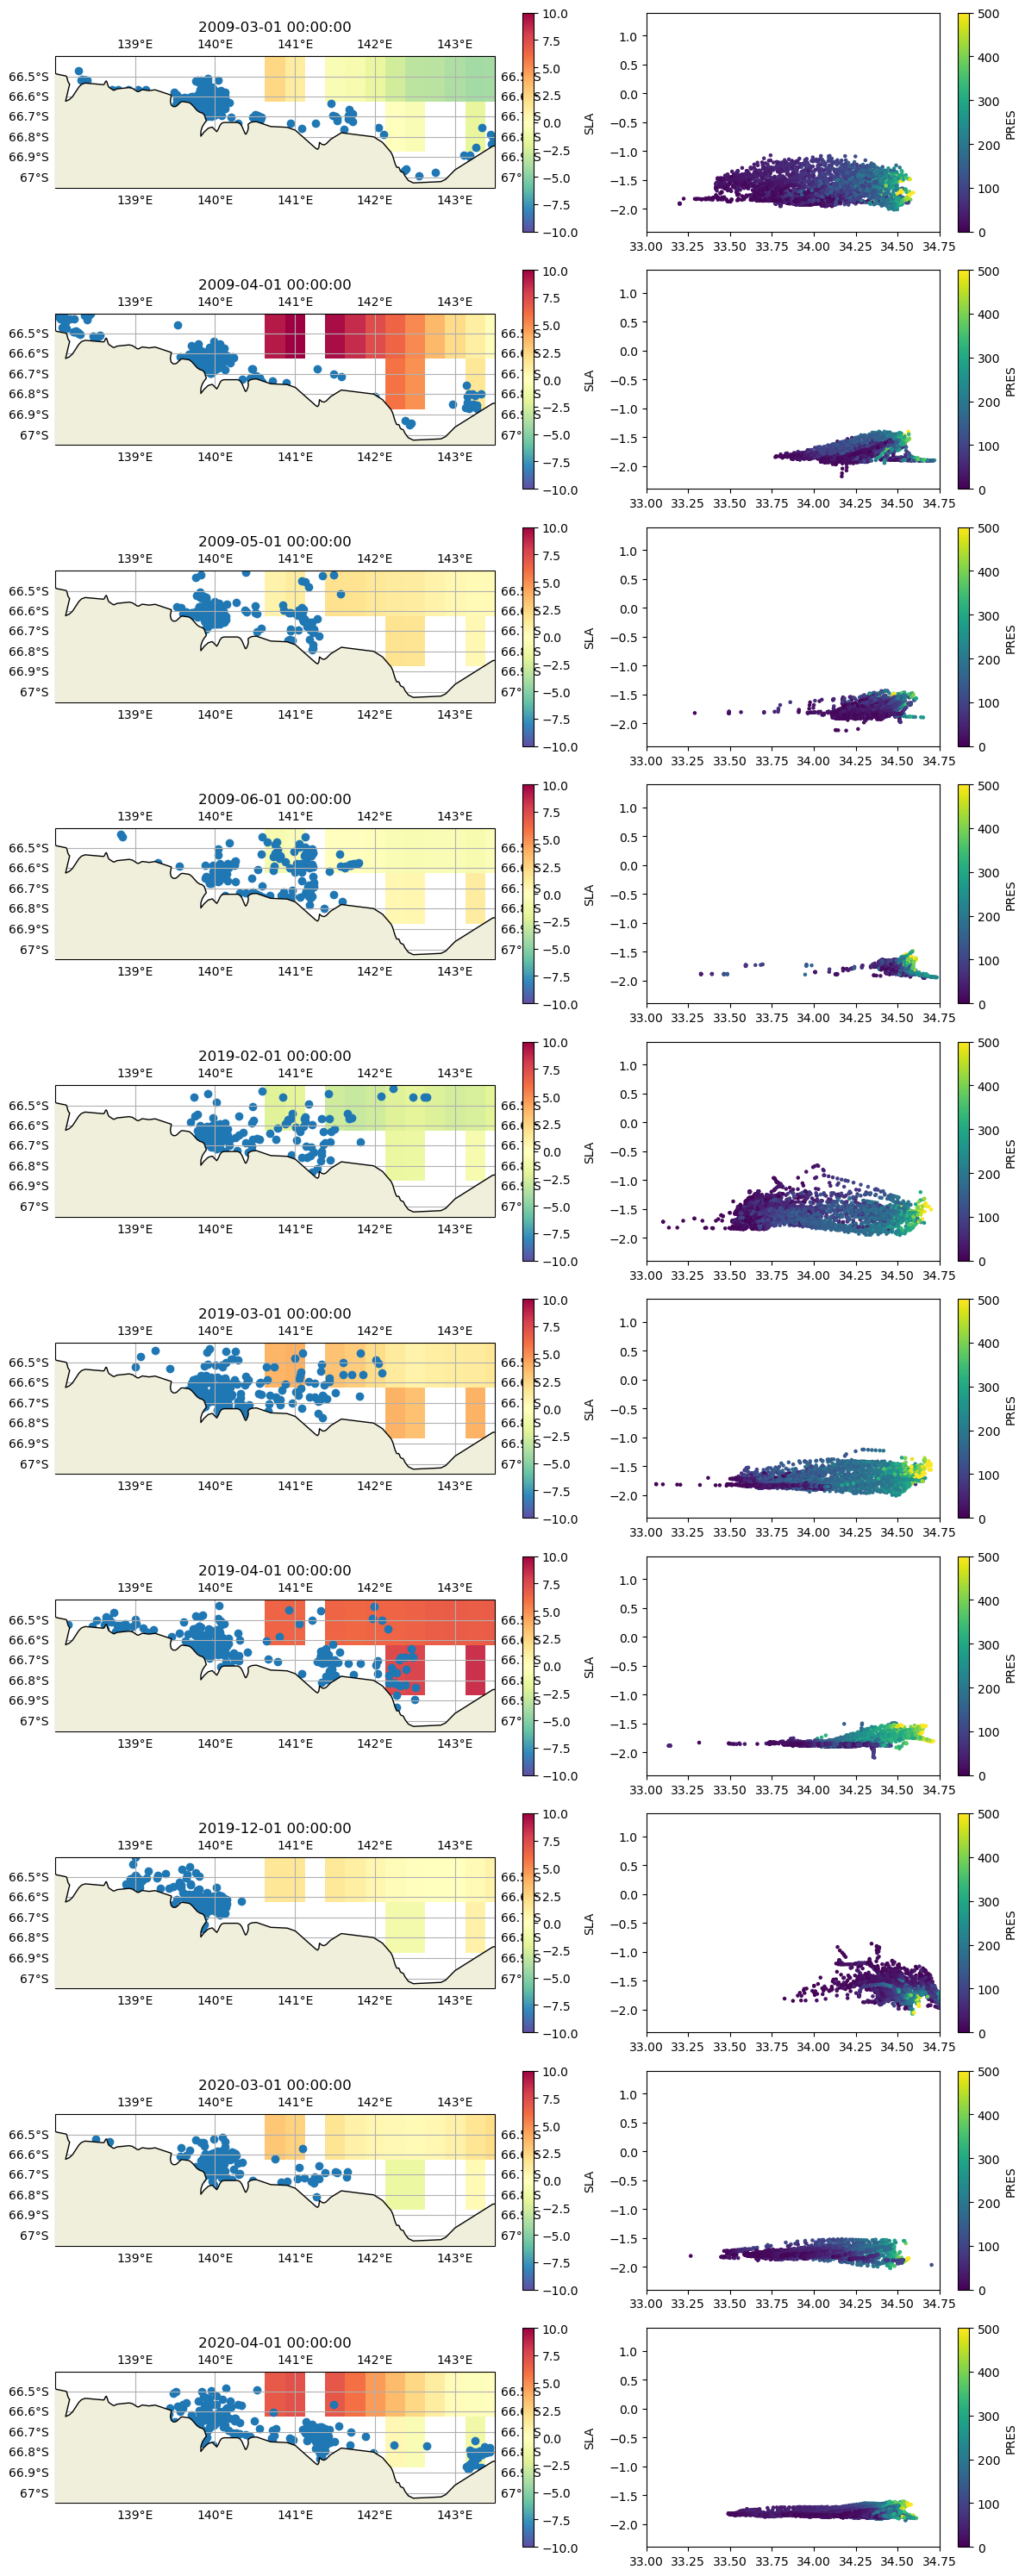

In [23]:
n=10
fig = plt.figure(figsize=(12,3*n))
axs=[]

gs = fig.add_gridspec(n,2,width_ratios=[3,2])

for i in np.arange(n):
    ts = meop.df.dropna().gph.groupby(pd.Grouper(freq='MS')).mean()[months].index[i]
    axs.append(fig.add_subplot(gs[i,0],projection=ccrs.Mercator()))
    axs.append(fig.add_subplot(gs[i,1]))
    radial_profile([axs[i*2],axs[(i*2)+1]],meop,ts)

In [24]:
# in order to combine many profiles to create a transect, we need to interpolate them onto the same vertical grid
# create a pressure index using the most commonly occurring values for profiles
allpres = np.concatenate([p.ds.pressure.to_numpy() for p in meop.profiles])
values, counts = np.unique(allpres[~np.isnan(allpres)], return_counts=True)
pressure_df = pd.DataFrame(counts,values)
pressure_axis= pressure_df[(pressure_df>1000).to_numpy().transpose().flatten()].index.to_numpy()


In [79]:
# function to take a profile and turn it into a ds with uniform z-axis and tagged with the longitude
def reindex_profile(profile,dim='longitude'):
    return profile.ds \
            .rename({'N_LEVELS':'pressure'}) \
            .dropna(dim='pressure',how='all') \
            .interp(coords={'pressure':pressure_axis}) \
            .assign_coords({dim:profile.get(dim)}) \
            .expand_dims(dim)
    

In [126]:
def dissect_month(ts,ns_section_lat=140):
    # Define limits:
    tmin = -2.2
    tmax = -0.9
    smin = 33.8
    smax = 34.8

    # Set up figre
    fig = plt.figure(figsize=(24,14))
    axs=[]

    gs = fig.add_gridspec(3,6)

    # Restrict data to within our chosen month
    print('Preparing data...')
    profiles = meop.filter_profiles(ts,ts+pd.DateOffset(months=1))
    profiles_df = meop.df[(meop.df.index > ts) & (meop.df.index < ts+pd.DateOffset(months=1))]

    # Extract profile data
    dses = []
    for p in tqdm(profiles):
        if not (np.all(np.isnan(p.ds.temperature)) and np.all(np.isnan(p.ds.salinity))):
            dses.append(reindex_profile(p))

    ds = xr.merge(dses)

    # Get data for selected transect
    print('Preparing data for n-s transect...')
    dses_transect = []
    for p in tqdm(profiles):
        if not (np.all(np.isnan(p.ds.temperature)) and np.all(np.isnan(p.ds.salinity))):
            if (p.longitude > (ns_section_lat - 0.2)) and (p.longitude < (ns_section_lat + 0.2)):
                dses_transect.append(reindex_profile(p,dim='latitude'))

    ds_transect = xr.merge(dses_transect)

    print('Creating figures...')
    # FIG A) SLA + PROFILE LOCATION
    axs.append(fig.add_subplot(gs[0,0:4],projection=ccrs.Mercator()))

    im=pfns.sp(ax=axs[0],da=sha_gph_.ssha.sel(time=ts),extent=extent,vmax=10)
    axs[0].scatter(profiles_df.longitude, profiles_df.latitude, transform=ccrs.PlateCarree())
    axs[0].set_title(ts)
    cbar = plt.colorbar(im, label='SLA')

    axs[0].add_patch(mpatches.Rectangle(xy=[ns_section_lat-0.2, extent[2]],
                                width=0.4,
                                height=extent[3]-extent[2],
                                facecolor='none', edgecolor='r',
                                transform=ccrs.PlateCarree()))

    # FIG B) COASTAL TRANSECT
    axs.append(fig.add_subplot(gs[1,0:4]))
    ds.temperature.plot.contourf(ax=axs[1],x='longitude',y='pressure',vmin=tmin,vmax=tmax,cmap='magma')
    axs[1].invert_yaxis()
    axs[1].set_xlabel('Longitude')
    axs[1].set_ylabel('Pressure/dbar')

    # FIG C) MEAN TEMPERATURE PROFILE
    axs.append(fig.add_subplot(gs[0:2,4]))

    for lon in ds.longitude:
        ds_ = ds.sel(longitude=lon)
        axs[2].plot(ds_.temperature,ds_.pressure,color='thistle')
    ds_mean=ds.mean('longitude')
    axs[2].plot(ds_mean.temperature,ds_mean.pressure,color='mediumvioletred')
    axs[2].invert_yaxis()
    axs[2].set_ylabel('Pressure')
    axs[2].set_xlabel('Temperature')
    axs[2].set_xlim([tmin,tmax])

    # FIG d) MEAN salinity PROFILE
    axs.append(fig.add_subplot(gs[0:2,5]))

    for lon in ds.longitude:
        ds_ = ds.sel(longitude=lon)
        axs[3].plot(ds_.salinity,ds_.pressure,color='lightblue')
    ds_mean=ds.mean('longitude')
    axs[3].plot(ds_mean.salinity,ds_mean.pressure,color='steelblue')
    axs[3].invert_yaxis()
    axs[3].set_ylabel('Pressure')
    axs[3].set_xlabel('Salinity')
    axs[3].set_xlim([smin,smax])

    # FIG E) T-S PLOT
    axs.append(fig.add_subplot(gs[2,0:2]))
    for profile in profiles:
        im=axs[4].scatter(profile.ds.salinity,profile.ds.temperature,5,profile.ds.pressure,vmin=0,vmax=500,cmap='winter')
    axs[4].set_ylim([tmin,tmax])
    axs[4].set_xlim([smin,smax])
    cbar = plt.colorbar(im, label='Pressure')

    # FIG F) N-S Transect Temperature
    axs.append(fig.add_subplot(gs[2,2:4]))
    ds_transect.temperature.plot.contourf(ax=axs[5],x='latitude',y='pressure',vmin=tmin,vmax=tmax,cmap='magma')
    axs[5].invert_yaxis()
    axs[5].set_xlabel('Latitude')
    axs[5].set_ylabel('Pressure/dbar')
    axs[5].set_title('N-S transect at {}E'.format(ns_section_lat))

    # FIG F) N-S Transect Salinity
    axs.append(fig.add_subplot(gs[2,4:6]))
    ds_transect.salinity.plot.contourf(ax=axs[6],x='latitude',y='pressure',vmin=smin,vmax=smax)
    axs[6].invert_yaxis()
    axs[6].set_xlabel('Latitude')
    axs[6].set_ylabel('Pressure/dbar')
    axs[6].set_title('N-S transect at {}E'.format(ns_section_lat))

    print('Rendering..')

    plt.tight_layout()


Preparing data...


100%|██████████| 232/232 [00:00<00:00, 234.58it/s]


Preparing data for n-s transect...


100%|██████████| 232/232 [00:00<00:00, 386.28it/s]


Creating figures...
Rendering..


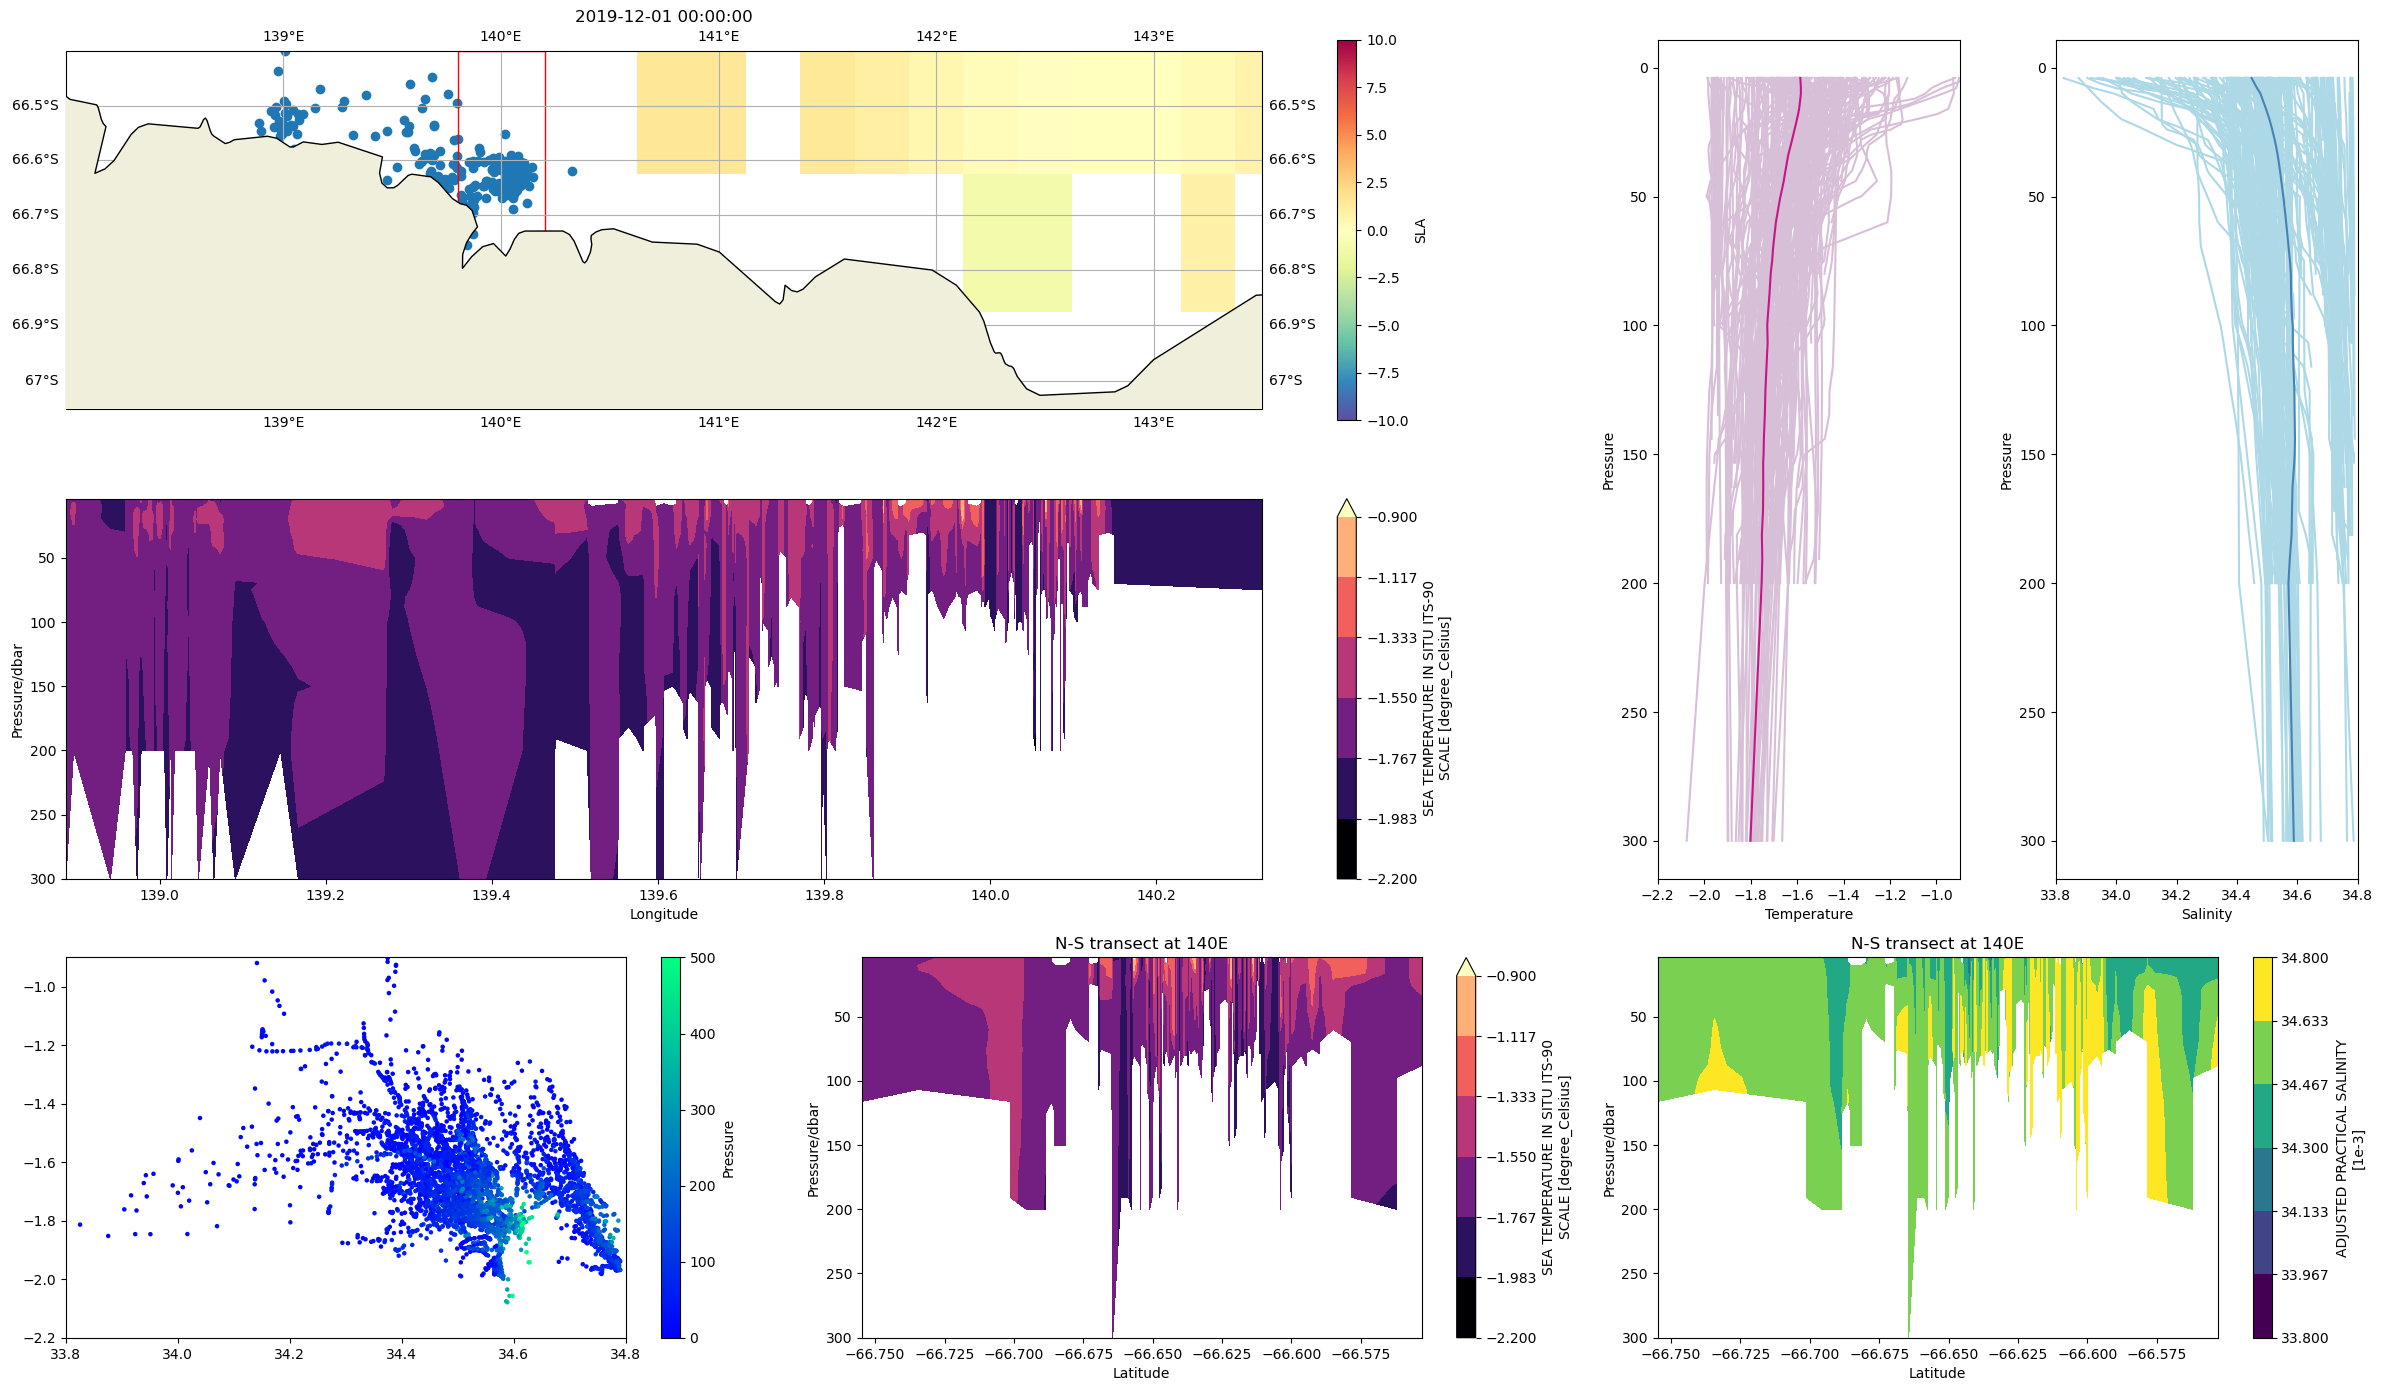

In [134]:
ts = pd.Timestamp(2019,12,1)
dissect_month(ts,140)
